<a href="https://colab.research.google.com/github/jonasknoll57/Bachelorarbeit_Demand-AD/blob/main/V1_AD_TL_Tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Zugangsberechtigung auf Drive

from google.colab import drive
drive.mount('/content/drive')

# Gezippte Daten werden entpackt und in hohes Verzeichnis gelegt

!cp "/content/drive/MyDrive/BA_Colab/data.zip" "/content/data.zip"

!unzip -q "/content/data.zip" -d "/content"

!rm "/content/data.zip"
!rm "/content/_MACOSX"


Mounted at /content/drive
rm: cannot remove '/content/_MACOSX': No such file or directory


In [2]:
# %%
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import geopandas as gpd
import glob, os, re
from shapely import wkb
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Pfade (konsistent mit Phase 1–4) ──────────────────────────────────────
DEMAND_BASE        = '/content/data/demand'           # Ordner mit Unterordnern pro Stadt
STATION_NAMES_PATH = '/content/data/station_names/station_names.parquet'
GEO_INFO_PATH      = '/content/data/geo_information/geo_information.parquet'
WEATHER_PATH       = '/content/data/weather/weather.parquet'
HOLIDAYS_PATH      = '/content/data/holidays/holidays.parquet'
VACATIONS_PATH     = '/content/data/vacations/vacations.parquet'

OUTPUT_DIR = Path('/content/processed')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Experiment-Städte aus Phase 4 ─────────────────────────────────────────
TARGET_NETWORKS = ['Mannheim', 'Heidelberg', 'Freiburg', 'Marburg']

# ── Anomalie-Parameter ────────────────────────────────────────────────────
FREQ           = '1h'
ANOMALY_SIGMA  = 2.0
ROLLING_WEEKS  = 4

print(f'Experiment-Städte: {TARGET_NETWORKS}')
print(f'Output: {OUTPUT_DIR}')

Experiment-Städte: ['Mannheim', 'Heidelberg', 'Freiburg', 'Marburg']
Output: /content/processed


In [3]:
# %%
def classify_station(name: str) -> str:
    if not isinstance(name, str) or name.strip() == '': return 'unknown'
    n = name.strip()
    if re.search(r'(?i)^recording[_\-\s]', n):  return 'recording'
    if re.match(r'(?i)^bike[-_]?\s*\d*', n):    return 'bike'
    if re.search(r'(?i)(virtuell|virtual)', n):  return 'virtual'
    if re.fullmatch(r'[\d\s\-_\.#/]+', n):      return 'only_nums'
    return 'real'

station_names = pd.read_parquet(STATION_NAMES_PATH)
station_names = station_names.rename(columns={'id': 'station_name_id', 'name': 'station_name'})
station_names['station_type'] = station_names['station_name'].apply(classify_station)
type_lookup = station_names.set_index('station_name_id')['station_type'].to_dict()
print(f'Station-Types: {station_names["station_type"].value_counts().to_dict()}')

Station-Types: {'bike': 44747, 'real': 13040, 'virtual': 4827, 'recording': 1972, 'only_nums': 51}


In [4]:
# %%
# ── GEO_INFO: WKB-Geometrie dekodieren (wie Phase 2) ──────────────────────
geo_info = pq.read_table(GEO_INFO_PATH).to_pandas()
geom = geo_info['location'].apply(lambda x: wkb.loads(bytes.fromhex(x)))
geo_info['latitude']  = geom.apply(lambda g: round(g.y, 6))
geo_info['longitude'] = geom.apply(lambda g: round(g.x, 6))
geo_info = geo_info.drop(columns=['location'])
print(f'GEO_INFO: {len(geo_info):,} Zeilen | Spalten: {list(geo_info.columns)}')

# ── Wetter ─────────────────────────────────────────────────────────────────
weather = pd.read_parquet(WEATHER_PATH)
weather['timestamp'] = pd.to_datetime(weather['timestamp'], utc=True)
print(f'Weather: {len(weather):,} Zeilen | Zeitraum: {weather["timestamp"].min().date()} – {weather["timestamp"].max().date()}')

# ── Feiertage & Ferien ─────────────────────────────────────────────────────
holidays  = pd.read_parquet(HOLIDAYS_PATH)
vacations = pd.read_parquet(VACATIONS_PATH)
holidays['start_date']  = pd.to_datetime(holidays['start_date'])
holidays['end_date']    = pd.to_datetime(holidays['end_date'])
vacations['start_date'] = pd.to_datetime(vacations['start_date'])
vacations['end_date']   = pd.to_datetime(vacations['end_date'])
print(f'Holidays: {len(holidays):,} | Vacations: {len(vacations):,}')

GEO_INFO: 300,508 Zeilen | Spalten: ['location_id', 'continent_name', 'country_name', 'city_name', 'federal_state_name', 'postal_code', 'elevation', 'latitude', 'longitude']
Weather: 17,628,201 Zeilen | Zeitraum: 2023-04-01 – 2026-02-02
Holidays: 2,757 | Vacations: 353


In [5]:
# %%
# Identische Lade-Logik wie Phase 2/3
# WICHTIG: Aggregationsebene ist station_id (echte Stations-ID),
# NICHT location_id (geografischer Standort — kann mehrere Stationen enthalten)
def load_city(city: str, base: str) -> pd.DataFrame | None:
    files = glob.glob(os.path.join(base, city, '**', '*.parquet'), recursive=True)
    if not files:
        files = glob.glob(os.path.join(base, city, '*.parquet'))
    if not files: return None
    cols = ['network_name', 'timestamp', 'station_id', 'station_name_id',
            'location_id', 'n_lends', 'n_returns']
    return pd.concat([pd.read_parquet(f, columns=cols) for f in files], ignore_index=True)

parts = []
for city in TARGET_NETWORKS:
    df = load_city(city, DEMAND_BASE)
    if df is None:
        print(f'  ⚠️  {city}: nicht gefunden'); continue
    df['timestamp']    = pd.to_datetime(df['timestamp'], utc=True)
    df['station_type'] = df['station_name_id'].map(type_lookup).fillna('unknown')

    # Nur echte Stationen — konsistent mit Phase 1–3
    df_real = df[df['station_type'] == 'real'].copy()
    parts.append(df_real)

    n_stations = df_real['station_id'].nunique()
    date_range = (df_real['timestamp'].max() - df_real['timestamp'].min()).days
    print(f'  ✅ {city}: {len(df_real):>8,} Zeilen | {n_stations} Stationen | {date_range} Tage')

demand = pd.concat(parts, ignore_index=True)
print(f'\nDEMAND gesamt: {len(demand):,} Zeilen | {demand["network_name"].nunique()} Netzwerke')

  ✅ Mannheim: 2,579,329 Zeilen | 128 Stationen | 1039 Tage
  ✅ Heidelberg: 1,873,100 Zeilen | 70 Stationen | 1039 Tage
  ✅ Freiburg:  872,531 Zeilen | 132 Stationen | 292 Tage
  ✅ Marburg: 1,837,213 Zeilen | 61 Stationen | 1039 Tage

DEMAND gesamt: 7,162,173 Zeilen | 4 Netzwerke


In [6]:
# %%
def aggregate_hourly(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregiert Demand auf stündliche Ebene pro Station.
    Aggregationsschlüssel: network_name + station_id + location_id + hour_ts

    station_id  = eindeutige Stations-ID (Aggregationsebene für AD)
    location_id = geografischer Standort (für spätere Wetter-/Geo-Joins)
    """
    df = df.copy()
    df['hour_ts'] = df['timestamp'].dt.floor('h')

    hourly = (
        df.groupby(['network_name', 'station_id', 'location_id', 'hour_ts'])
        .agg(n_lends=('n_lends', 'sum'), n_returns=('n_returns', 'sum'))
        .reset_index()
    )
    hourly['net_flow']     = hourly['n_lends'] - hourly['n_returns']
    hourly['total_demand'] = hourly['n_lends'] + hourly['n_returns']
    return hourly

hourly_demand = aggregate_hourly(demand)
print(f'Hourly Demand: {hourly_demand.shape[0]:,} Zeilen')
print(f'Spalten: {list(hourly_demand.columns)}')
hourly_demand.head()

Hourly Demand: 2,807,533 Zeilen
Spalten: ['network_name', 'station_id', 'location_id', 'hour_ts', 'n_lends', 'n_returns', 'net_flow', 'total_demand']


,network_name,station_id,location_id,hour_ts,n_lends,n_returns,net_flow,total_demand
0,Freiburg,148616581,197623,2025-04-16 14:00:00+00:00,1,1,0,2
1,Freiburg,148616581,197623,2025-04-16 15:00:00+00:00,2,2,0,4
2,Freiburg,148616581,197623,2025-04-16 18:00:00+00:00,2,0,2,2
3,Freiburg,148616581,197623,2025-04-16 20:00:00+00:00,1,0,1,1
4,Freiburg,148616581,197623,2025-04-17 07:00:00+00:00,0,3,-3,3


In [7]:
# %%
def fill_hourly_gaps(hourly: pd.DataFrame) -> pd.DataFrame:
    """Erzeugt lückenlose stündliche Zeitreihe pro Station mit 0-Fill."""
    filled_parts = []

    for network in hourly['network_name'].unique():
        net_data = hourly[hourly['network_name'] == network]
        t_min = net_data['hour_ts'].min()
        t_max = net_data['hour_ts'].max()
        full_range = pd.date_range(t_min, t_max, freq='h', tz='UTC')

        for station_id in net_data['station_id'].unique():
            s = net_data[net_data['station_id'] == station_id].copy()
            loc_id = s['location_id'].iloc[0]

            # Duplikate aggregieren: mehrere Transaktionen in derselben Stunde summieren
            s = (
                s.groupby('hour_ts')
                [['n_lends', 'n_returns', 'net_flow', 'total_demand']]
                .sum()
            )

            # Jetzt erst reindex — Index ist garantiert eindeutig
            s = s.reindex(full_range, fill_value=0)
            s.index.name = 'hour_ts'
            s['network_name'] = network
            s['station_id']   = station_id
            s['location_id']  = loc_id
            filled_parts.append(s.reset_index())

    return pd.concat(filled_parts, ignore_index=True)

print('Fülle Zeitreihen-Lücken …')
hourly_full = fill_hourly_gaps(hourly_demand)
print(f'Vorher: {hourly_demand.shape[0]:,} | Nachher: {hourly_full.shape[0]:,} '
      f'(+{hourly_full.shape[0]-hourly_demand.shape[0]:,} Nullstunden)')

Fülle Zeitreihen-Lücken …
Vorher: 2,807,533 | Nachher: 7,385,323 (+4,577,790 Nullstunden)


In [8]:
# ## Cell 7 — Wetter-Features (pro Netzwerk, feste Wetterstationen)
#
# Wetterdaten existieren nur an 1–2 location_ids pro Stadt.
# → Explizites Mapping: Netzwerk → Wetterstation-location_id
# → Heidelberg nutzt Mannheim (geografische Nähe, keine eigene Station)

# %%
# ── Mapping: Netzwerk → Wetterstation location_id ──
WEATHER_STATION_MAP = {
    'Mannheim':   292348,
    'Heidelberg': 292348,   # Keine eigene Station → Mannheim
    'Freiburg':   292302,
    'Marburg':    292318,
}

weather['hour_ts'] = weather['timestamp'].dt.floor('h')

# Nur relevante Wetterstationen laden
weather_station_ids = list(set(WEATHER_STATION_MAP.values()))
weather_filtered = weather[weather['location_id'].isin(weather_station_ids)].copy()

print(f'Wetter-Zeilen (nur relevante Stationen): {len(weather_filtered):,}')
for loc_id in weather_station_ids:
    n = len(weather_filtered[weather_filtered['location_id'] == loc_id])
    print(f'  location_id {loc_id}: {n:,} Zeilen')

# Aggregiere auf Stunde pro Wetterstation
weather_hourly = (
    weather_filtered
    .groupby(['location_id', 'hour_ts'])
    .agg(
        temperature   = ('temperature', 'mean'),
        humidity      = ('humidity', 'mean'),
        precipitation = ('precipitation', 'sum'),    # Summe → Stundenniederschlag
        wind_speed    = ('wind_speed', 'mean'),
    )
    .reset_index()
)

# ── Netzwerk-Spalte hinzufügen (Reverse-Mapping) ──
# Ein location_id kann für mehrere Netzwerke gelten (z.B. 292348 → MA + HD)
weather_rows = []
for network, weather_loc in WEATHER_STATION_MAP.items():
    w = weather_hourly[weather_hourly['location_id'] == weather_loc].copy()
    w['network_name'] = network
    weather_rows.append(w)

weather_by_network = pd.concat(weather_rows, ignore_index=True)
weather_by_network = weather_by_network.drop(columns=['location_id'])

print(f'\nWetter pro Netzwerk×Stunde: {len(weather_by_network):,} Zeilen')

# ── Join: über network_name + hour_ts (nicht mehr location_id!) ──
hourly_full = hourly_full.merge(
    weather_by_network,
    on=['network_name', 'hour_ts'],
    how='left'
)

# ── Interpolation für kurze Lücken ──
for col in ['temperature', 'humidity', 'precipitation', 'wind_speed']:
    hourly_full[col] = (
        hourly_full
        .groupby(['network_name', 'station_id'])[col]
        .transform(lambda x: x.interpolate(method='linear', limit=6).ffill().bfill())
    )

# ── Coverage prüfen ──
print(f'\nWetter-Coverage nach Join + Interpolation:')
for net in TARGET_NETWORKS:
    d = hourly_full[hourly_full['network_name'] == net]
    cov = d['temperature'].notna().mean() * 100
    station_id = WEATHER_STATION_MAP[net]
    print(f'  {net:<12} → Station {station_id}: {cov:.1f}%')

total_cov = hourly_full['temperature'].notna().mean() * 100
print(f'\n  Gesamt: {total_cov:.1f}%')

Wetter-Zeilen (nur relevante Stationen): 448,419
  location_id 292348: 149,473 Zeilen
  location_id 292318: 149,473 Zeilen
  location_id 292302: 149,473 Zeilen

Wetter pro Netzwerk×Stunde: 99,652 Zeilen

Wetter-Coverage nach Join + Interpolation:
  Mannheim     → Station 292348: 100.0%
  Heidelberg   → Station 292348: 100.0%
  Freiburg     → Station 292302: 100.0%
  Marburg      → Station 292318: 100.0%

  Gesamt: 100.0%


In [9]:
# ## Cell 8 — Kalender-Features (Feiertage, Ferien, zyklische Kodierung)

# %%
def add_calendar_features(df, holidays_df, vacations_df, geo_df):
    df = df.copy()
    ts = pd.to_datetime(df['hour_ts'], utc=True)

    # ── Basis ──
    df['hour']       = ts.dt.hour
    df['dayofweek']  = ts.dt.dayofweek          # 0=Mo, 6=So
    df['month']      = ts.dt.month
    df['is_weekend'] = (ts.dt.dayofweek >= 5).astype(int)
    df['date']       = ts.dt.date

    # ── Bundesland pro Station (über location_id → geo_info) ──
    loc_to_state = geo_df[['location_id', 'federal_state_name']].drop_duplicates('location_id')
    df = df.merge(loc_to_state, on='location_id', how='left')

    # ── Feiertage: Set-Lookup ──
    holiday_set = set()
    for _, row in holidays_df.iterrows():
        for d in pd.date_range(row['start_date'], row['end_date'], freq='D'):
            holiday_set.add((d.date(), row['federal_state_name']))

    df['is_holiday'] = df.apply(
        lambda r: int((r['date'], r.get('federal_state_name', '')) in holiday_set),
        axis=1
    )

    # ── Ferien: Set-Lookup ──
    vacation_sets = {}
    for _, row in vacations_df.iterrows():
        state = row['federal_state_name']
        if state not in vacation_sets:
            vacation_sets[state] = set()
        for d in pd.date_range(row['start_date'], row['end_date'], freq='D'):
            vacation_sets[state].add(d.date())

    df['is_vacation'] = df.apply(
        lambda r: int(r['date'] in vacation_sets.get(r.get('federal_state_name', ''), set())),
        axis=1
    )

    print(f'  Feiertag-Stunden: {df["is_holiday"].sum():,}')
    print(f'  Ferien-Stunden:   {df["is_vacation"].sum():,}')

    # ── Zyklische Kodierung (für neuronales Netz) ──
    df['hour_sin']  = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin']   = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos']   = np.cos(2 * np.pi * df['dayofweek'] / 7)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    return df

print('Kalender-Features …')
hourly_full = add_calendar_features(hourly_full, holidays, vacations, geo_info)
print('✓ Fertig')

Kalender-Features …
  Feiertag-Stunden: 838,416
  Ferien-Stunden:   1,498,872
✓ Fertig


In [10]:
# ## Cell 9 — Lag-Features
#
# Für den Autoencoder: Was war die Nachfrage in der Vergangenheit?
# - `lag_1h`, `lag_2h`: kurzfristig
# - `lag_24h`: gleiche Stunde gestern
# - `lag_168h`: gleiche Stunde letzte Woche
# - `rolling_mean_24h` / `rolling_std_24h`: gleitender Tagestrend

# %%
def add_lag_features(df):
    """Lag- und Rolling-Features pro Station (station_id)."""
    df = df.sort_values(['network_name', 'station_id', 'hour_ts']).copy()

    lags = {'lag_1h': 1, 'lag_2h': 2, 'lag_24h': 24, 'lag_168h': 168}

    for target in ['n_lends', 'n_returns']:
        grp = df.groupby(['network_name', 'station_id'])[target]

        for lag_name, lag_val in lags.items():
            df[f'{target}_{lag_name}'] = grp.shift(lag_val)

        df[f'{target}_rolling_mean_24h'] = grp.transform(
            lambda x: x.rolling(24, min_periods=12).mean()
        )
        df[f'{target}_rolling_std_24h'] = grp.transform(
            lambda x: x.rolling(24, min_periods=12).std()
        )

    return df

print('Lag-Features …')
hourly_full = add_lag_features(hourly_full)

nan_pct = hourly_full['n_lends_lag_168h'].isna().mean() * 100
print(f'NaN durch Lag-168h: {nan_pct:.1f}% (erste Woche pro Station)')


Lag-Features …
NaN durch Lag-168h: 0.9% (erste Woche pro Station)


In [11]:
# ## Cell 10 — Anomalie-Labels (Option C: Regelbasiert, >2σ)
#
# **Zwei Methoden, kombiniertes Label:**
# 1. **Profil-basiert:** Abweichung vom historischen Mittel (hour × dayofweek pro Station)
# 2. **Rolling-basiert:** Abweichung vom gleitenden 24h-Fenster
# 3. **Combined:** Beide müssen zustimmen → weniger False Positives

# %%
def generate_anomaly_labels(df, sigma=2.0):
    df = df.copy()

    # ── Methode 1: Profil-basiert (hour × dayofweek pro Station) ──
    profile = (
        df.groupby(['network_name', 'station_id', 'hour', 'dayofweek'])
        .agg(
            expected_lends   = ('n_lends', 'mean'),
            std_lends        = ('n_lends', 'std'),
            expected_returns = ('n_returns', 'mean'),
            std_returns      = ('n_returns', 'std'),
        )
        .reset_index()
    )
    # Mindest-Std: verhindert Division durch 0 bei inaktiven Stunden
    profile['std_lends']   = profile['std_lends'].clip(lower=0.5)
    profile['std_returns'] = profile['std_returns'].clip(lower=0.5)

    df = df.merge(profile, on=['network_name', 'station_id', 'hour', 'dayofweek'], how='left')

    df['z_score_lends']   = (df['n_lends'] - df['expected_lends']) / df['std_lends']
    df['z_score_returns'] = (df['n_returns'] - df['expected_returns']) / df['std_returns']

    df['is_anomaly_profile'] = (
        (df['z_score_lends'].abs() > sigma) |
        (df['z_score_returns'].abs() > sigma)
    ).astype(int)

    # ── Methode 2: Rolling-basiert ──
    df['z_rolling_lends'] = np.where(
        df['n_lends_rolling_std_24h'] > 0.5,
        (df['n_lends'] - df['n_lends_rolling_mean_24h']) / df['n_lends_rolling_std_24h'],
        0
    )
    df['z_rolling_returns'] = np.where(
        df['n_returns_rolling_std_24h'] > 0.5,
        (df['n_returns'] - df['n_returns_rolling_mean_24h']) / df['n_returns_rolling_std_24h'],
        0
    )

    df['is_anomaly_rolling'] = (
        (df['z_rolling_lends'].abs() > sigma) |
        (df['z_rolling_returns'].abs() > sigma)
    ).astype(int)

    # ── Methode 3: Combined (Intersection) ──
    df['is_anomaly'] = (
        (df['is_anomaly_profile'] == 1) & (df['is_anomaly_rolling'] == 1)
    ).astype(int)

    return df

print(f'Anomalie-Labels (σ = {ANOMALY_SIGMA}) …\n')
hourly_full = generate_anomaly_labels(hourly_full, sigma=ANOMALY_SIGMA)

print(f'{"Netzwerk":<15} {"Gesamt":>12} {"Profil":>14} {"Rolling":>14} {"Combined":>14}')
print('─' * 72)
for net in TARGET_NETWORKS:
    d = hourly_full[hourly_full['network_name'] == net]
    n = len(d)
    p = d['is_anomaly_profile'].sum()
    r = d['is_anomaly_rolling'].sum()
    c = d['is_anomaly'].sum()
    print(f'{net:<15} {n:>12,}   {p:>6,} ({p/n*100:4.1f}%)   '
          f'{r:>6,} ({r/n*100:4.1f}%)   {c:>6,} ({c/n*100:4.1f}%)')


Anomalie-Labels (σ = 2.0) …

Netzwerk              Gesamt         Profil        Rolling       Combined
────────────────────────────────────────────────────────────────────────
Mannheim           3,191,936   145,725 ( 4.6%)   176,739 ( 5.5%)   83,978 ( 2.6%)
Heidelberg         1,745,590   100,210 ( 5.7%)   117,765 ( 6.7%)   58,479 ( 3.4%)
Freiburg             926,640   51,347 ( 5.5%)   62,800 ( 6.8%)   30,310 ( 3.3%)
Marburg            1,521,157   91,532 ( 6.0%)   102,618 ( 6.7%)   47,750 ( 3.1%)


In [12]:
# ## Cell 11 — Export: 1 Parquet pro Stadt

# %%
EXPORT_COLS = [
    # IDs
    'network_name', 'station_id', 'location_id', 'hour_ts',
    # Demand
    'n_lends', 'n_returns', 'net_flow', 'total_demand',
    # Kalender
    'hour', 'dayofweek', 'month', 'is_weekend', 'is_holiday', 'is_vacation',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    # Wetter
    'temperature', 'humidity', 'precipitation', 'wind_speed',
    # Lags — Lends
    'n_lends_lag_1h', 'n_lends_lag_2h', 'n_lends_lag_24h', 'n_lends_lag_168h',
    'n_lends_rolling_mean_24h', 'n_lends_rolling_std_24h',
    # Lags — Returns
    'n_returns_lag_1h', 'n_returns_lag_2h', 'n_returns_lag_24h', 'n_returns_lag_168h',
    'n_returns_rolling_mean_24h', 'n_returns_rolling_std_24h',
    # Profil (als Input-Feature nutzbar)
    'expected_lends', 'expected_returns',
    # Labels
    'is_anomaly', 'is_anomaly_profile', 'is_anomaly_rolling',
    'z_score_lends', 'z_score_returns',
]

existing_cols = [c for c in EXPORT_COLS if c in hourly_full.columns]

for net in TARGET_NETWORKS:
    net_data = hourly_full[hourly_full['network_name'] == net][existing_cols].copy()
    # Droppe erste Woche pro Station (NaN durch Lag-168h)
    net_data = net_data.dropna(subset=['n_lends_lag_168h'])

    filepath = OUTPUT_DIR / f'{net.lower()}_hourly.parquet'
    net_data.to_parquet(filepath, index=False)

    n_anom = net_data['is_anomaly'].sum()
    print(f'  ✅ {net:<12} {net_data.shape[0]:>10,} Zeilen | '
          f'{net_data["station_id"].nunique():>4} Stationen | '
          f'{n_anom:>6,} Anomalien ({n_anom/len(net_data)*100:.1f}%) '
          f'→ {filepath.name}')

print(f'\n✓ Export abgeschlossen → {OUTPUT_DIR}/')

  ✅ Mannheim      3,170,432 Zeilen |  128 Stationen | 83,584 Anomalien (2.6%) → mannheim_hourly.parquet
  ✅ Heidelberg    1,733,830 Zeilen |   70 Stationen | 58,308 Anomalien (3.4%) → heidelberg_hourly.parquet
  ✅ Freiburg        904,464 Zeilen |  132 Stationen | 29,790 Anomalien (3.3%) → freiburg_hourly.parquet
  ✅ Marburg       1,510,909 Zeilen |   61 Stationen | 47,644 Anomalien (3.2%) → marburg_hourly.parquet

✓ Export abgeschlossen → /content/processed/


In [19]:
# ## Cell 12 — Mannheim laden & GPU-Check

# %%
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, precision_recall_curve, auc
import pickle

# ── GPU-Check ──
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU: {gpus[0].name}')
    # Memory Growth: nur so viel VRAM allokieren wie nötig
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f'Mixed Precision: aktiviert (float16 compute, float32 weights)')
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
else:
    print('⚠️ Keine GPU erkannt — Training auf CPU')

mannheim = pd.read_parquet(OUTPUT_DIR / 'mannheim_hourly.parquet')
mannheim = mannheim.sort_values(['station_id', 'hour_ts']).reset_index(drop=True)

print(f'\nMannheim:       {mannheim.shape[0]:,} Zeilen | '
      f'{mannheim["station_id"].nunique()} Stationen')
print(f'Zeitraum:       {mannheim["hour_ts"].min()} – {mannheim["hour_ts"].max()}')
print(f'Anomalie-Rate:  {mannheim["is_anomaly"].mean()*100:.2f}%')


GPU: /physical_device:GPU:0
Mixed Precision: aktiviert (float16 compute, float32 weights)

Mannheim:       3,170,432 Zeilen | 128 Stationen
Zeitraum:       2023-04-07 23:00:00+00:00 – 2026-02-02 23:00:00+00:00
Anomalie-Rate:  2.64%


In [20]:
# ## Cell 13 — Feature-Auswahl, Train/Test Split, Normalisierung

# %%
AE_FEATURES = [
    # Demand
    'n_lends', 'n_returns', 'net_flow', 'total_demand',
    # Kalender (zyklisch)
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'is_weekend', 'is_holiday', 'is_vacation',
    # Wetter
    'temperature', 'humidity', 'precipitation', 'wind_speed',
    # Lags
    'n_lends_lag_1h', 'n_lends_lag_2h', 'n_lends_lag_24h', 'n_lends_lag_168h',
    'n_lends_rolling_mean_24h',
    'n_returns_lag_1h', 'n_returns_lag_2h', 'n_returns_lag_24h', 'n_returns_lag_168h',
    'n_returns_rolling_mean_24h',
    # Profil-Erwartungswert
    'expected_lends', 'expected_returns',
]

LABEL_COL = 'is_anomaly'

# ── Zeitbasierter Split (80/20 chronologisch) ──
split_date = mannheim['hour_ts'].quantile(0.8)
train_df = mannheim[mannheim['hour_ts'] < split_date].copy()
test_df  = mannheim[mannheim['hour_ts'] >= split_date].copy()

print(f'Split:   {split_date}')
print(f'Train:   {train_df.shape[0]:>10,}  ({train_df[LABEL_COL].mean()*100:.2f}% Anomalien)')
print(f'Test:    {test_df.shape[0]:>10,}  ({test_df[LABEL_COL].mean()*100:.2f}% Anomalien)')

# ── Semi-supervised: nur normale Daten ──
train_normal = train_df[train_df[LABEL_COL] == 0]
print(f'Normal:  {train_normal.shape[0]:>10,}  (Training-Set)')

# ── Normalisierung ──
X_train = train_normal[AE_FEATURES].fillna(0).values.astype('float32')
X_test  = test_df[AE_FEATURES].fillna(0).values.astype('float32')
y_test  = test_df[LABEL_COL].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

INPUT_DIM = X_train_scaled.shape[1]
print(f'\nFeature-Dim: {INPUT_DIM}')


Split:   2025-07-11 14:00:00+00:00
Train:    2,536,320  (2.66% Anomalien)
Test:       634,112  (2.54% Anomalien)
Normal:   2,468,842  (Training-Set)

Feature-Dim: 29


In [21]:
# ## Cell 14 — Autoencoder Modell-Definition (Keras)

# %%
LATENT_DIM = 16

def build_autoencoder(input_dim, latent_dim=16):
    """
    Symmetrischer Autoencoder: Input → 64 → 32 → 16 → 32 → 64 → Input
    """
    encoder_input = tf.keras.Input(shape=(input_dim,), name='encoder_input')

    # Encoder
    x = tf.keras.layers.Dense(64, activation='relu', name='enc_1')(encoder_input)
    x = tf.keras.layers.Dropout(0.1)(x)
    x = tf.keras.layers.Dense(32, activation='relu', name='enc_2')(x)
    x = tf.keras.layers.Dropout(0.1)(x)
    encoded = tf.keras.layers.Dense(latent_dim, activation='relu', name='bottleneck')(x)

    # Decoder
    x = tf.keras.layers.Dense(32, activation='relu', name='dec_1')(encoded)
    x = tf.keras.layers.Dropout(0.1)(x)
    x = tf.keras.layers.Dense(64, activation='relu', name='dec_2')(x)
    x = tf.keras.layers.Dropout(0.1)(x)
    decoded = tf.keras.layers.Dense(input_dim, name='output')(x)

    autoencoder = tf.keras.Model(encoder_input, decoded, name='DemandAutoencoder')
    encoder     = tf.keras.Model(encoder_input, encoded, name='Encoder')

    return autoencoder, encoder

model, encoder = build_autoencoder(INPUT_DIM, LATENT_DIM)
model.summary()


Model: "DemandAutoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (Dense)                   │ (None, 64)             │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_2 (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_2 (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 29)             │         1,885 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,069 (35.43 KB)

 Trainable params: 9,069 (35.43 KB)

 Non-trainable params: 0 (0.00 B)

Anomaly Detection Training

In [22]:
# ## Cell 15 — Training (GPU-optimiert, L4)

# %%
BATCH_SIZE          = 2048
EPOCHS              = 100
LEARNING_RATE       = 1e-3

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='mse',
)

callbacks = [
    # Early Stopping
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    # LR Reduction bei Stagnation
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
]

# 10% der Train-Daten als Validation (für Early Stopping / LR Scheduler)
history = model.fit(
    X_train_scaled, X_train_scaled,    # Input = Target (Reconstruction)
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1,
)

print(f'\nBeste Val-Loss: {min(history.history["val_loss"]):.6f}')

Epoch 1/100
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - loss: 0.4824 - val_loss: 0.3077 - learning_rate: 0.0010
Epoch 2/100
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2550 - val_loss: 0.2503 - learning_rate: 0.0010
Epoch 3/100
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2319 - val_loss: 0.2145 - learning_rate: 0.0010
Epoch 4/100
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2192 - val_loss: 0.2024 - learning_rate: 0.0010
Epoch 5/100
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2116 - val_loss: 0.1992 - learning_rate: 0.0010
Epoch 6/100
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2064 - val_loss: 0.1909 - learning_rate: 0.0010
Epoch 7/100
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2023 - val_loss: 0.1851 - learning_rate: 0.0010
Epoch 8/100
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1980 - val_loss: 0.1876 - learning_rate: 0.0010
Epoch 9/100
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1946 - val_loss: 0.1866 - lea

In [23]:
# ## Cell 16 — Evaluation auf Mannheim Test-Set

# %%
# ── Reconstruction Error = MSE pro Sample ──
train_recon = model.predict(X_train_scaled, batch_size=4096, verbose=0)
test_recon  = model.predict(X_test_scaled,  batch_size=4096, verbose=0)

train_errors = np.mean((X_train_scaled - train_recon) ** 2, axis=1)
test_errors  = np.mean((X_test_scaled  - test_recon)  ** 2, axis=1)

# Thresholds aus Train-Verteilung
threshold_p95 = np.percentile(train_errors, 95)
threshold_p99 = np.percentile(train_errors, 99)

print(f'Train RE:  mean={train_errors.mean():.4f}  std={train_errors.std():.4f}  '
      f'P95={threshold_p95:.4f}  P99={threshold_p99:.4f}')
print(f'Test RE:   mean={test_errors.mean():.4f}  std={test_errors.std():.4f}')

# ── PR-AUC ──
prec_curve, rec_curve, _ = precision_recall_curve(y_test, test_errors)
pr_auc = auc(rec_curve, prec_curve)
print(f'\nPR-AUC: {pr_auc:.4f}')

# ── Classification Reports ──
for name, thr in [('P95', threshold_p95), ('P99', threshold_p99)]:
    y_pred = (test_errors > thr).astype(int)
    print(f'\n{"="*55}')
    print(f'Threshold {name} = {thr:.4f}  →  '
          f'{y_pred.sum():,}/{len(y_pred):,} predicted ({y_pred.mean()*100:.1f}%)')
    print(f'{"="*55}')
    print(classification_report(y_test, y_pred,
                                target_names=['Normal', 'Anomaly'],
                                zero_division=0))

Train RE:  mean=0.0931  std=0.2084  P95=0.3257  P99=0.9187
Test RE:   mean=0.0961  std=0.2315

PR-AUC: 0.1294

Threshold P95 = 0.3257  →  31,953/634,112 predicted (5.0%)
              precision    recall  f1-score   support

      Normal       0.98      0.96      0.97    618006
     Anomaly       0.14      0.27      0.18     16106

    accuracy                           0.94    634112
   macro avg       0.56      0.61      0.57    634112
weighted avg       0.96      0.94      0.95    634112


Threshold P99 = 0.9187  →  7,050/634,112 predicted (1.1%)
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98    618006
     Anomaly       0.19      0.08      0.12     16106

    accuracy                           0.97    634112
   macro avg       0.58      0.54      0.55    634112
weighted avg       0.96      0.97      0.96    634112



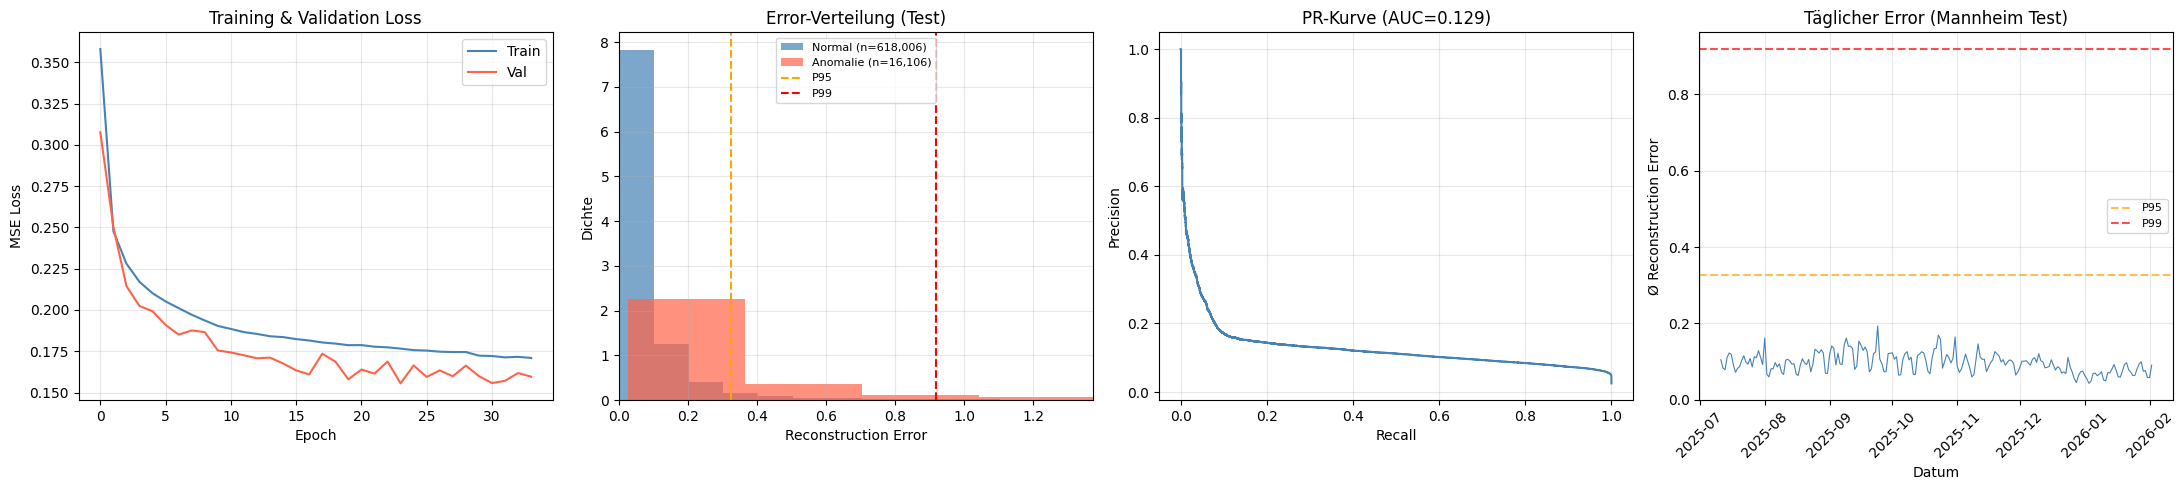

In [24]:
# ## Cell 17 — Visualisierung

# %%
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# 1) Training & Validation Loss
axes[0].plot(history.history['loss'],     label='Train', color='steelblue', lw=1.5)
axes[0].plot(history.history['val_loss'], label='Val',   color='tomato',    lw=1.5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# 2) Error-Verteilung
normal_err  = test_errors[y_test == 0]
anomaly_err = test_errors[y_test == 1]
axes[1].hist(normal_err, bins=100, alpha=0.7,
             label=f'Normal (n={len(normal_err):,})', color='steelblue', density=True)
if len(anomaly_err) > 0:
    axes[1].hist(anomaly_err, bins=100, alpha=0.7,
                 label=f'Anomalie (n={len(anomaly_err):,})', color='tomato', density=True)
axes[1].axvline(threshold_p95, color='orange', ls='--', label='P95')
axes[1].axvline(threshold_p99, color='red',    ls='--', label='P99')
axes[1].set_xlabel('Reconstruction Error'); axes[1].set_ylabel('Dichte')
axes[1].set_title('Error-Verteilung (Test)')
axes[1].legend(fontsize=8)
axes[1].set_xlim(0, np.percentile(test_errors, 99.5))
axes[1].grid(True, alpha=0.3)

# 3) PR-Kurve
axes[2].plot(rec_curve, prec_curve, color='steelblue', lw=1.5)
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title(f'PR-Kurve (AUC={pr_auc:.3f})')
axes[2].grid(True, alpha=0.3)

# 4) Täglicher Error über Zeit
test_plot = test_df.copy()
test_plot['recon_error'] = test_errors
daily = test_plot.groupby(test_plot['hour_ts'].dt.date)['recon_error'].mean()
axes[3].plot(daily.index, daily.values, color='steelblue', lw=0.8)
axes[3].axhline(threshold_p95, color='orange', ls='--', alpha=0.7, label='P95')
axes[3].axhline(threshold_p99, color='red',    ls='--', alpha=0.7, label='P99')
axes[3].set_xlabel('Datum'); axes[3].set_ylabel('Ø Reconstruction Error')
axes[3].set_title('Täglicher Error (Mannheim Test)')
axes[3].legend(fontsize=8)
axes[3].tick_params(axis='x', rotation=45)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'mannheim_ae_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# ## Cell 18 — Modell & Scaler speichern

# %%
# ── Keras-Modell speichern (ganzes Modell inkl. Architektur + Weights) ──
model.save(OUTPUT_DIR / 'mannheim_ae_model.keras')

# ── Metadaten separat (Thresholds, Features, etc.) ──
import json
metadata = {
    'input_dim':       INPUT_DIM,
    'latent_dim':      LATENT_DIM,
    'threshold_p95':   float(threshold_p95),
    'threshold_p99':   float(threshold_p99),
    'pr_auc':          float(pr_auc),
    'feature_columns': AE_FEATURES,
    'best_val_loss':   float(min(history.history['val_loss'])),
}
with open(OUTPUT_DIR / 'mannheim_ae_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

# ── Scaler ──
with open(OUTPUT_DIR / 'mannheim_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f'✓ Modell:    {OUTPUT_DIR}/mannheim_ae_model.keras')
print(f'✓ Metadata:  {OUTPUT_DIR}/mannheim_ae_metadata.json')
print(f'✓ Scaler:    {OUTPUT_DIR}/mannheim_scaler.pkl')

print(f'\n{"─"*55}')
print('Nächster Schritt → 02_cross_city_transfer.ipynb')
print('  tf.keras.models.load_model("mannheim_ae_model.keras")')
print('  → Freeze Encoder → Fine-tune Decoder auf Target City')
print(f'{"─"*55}')

✓ Modell:    /content/processed/mannheim_ae_model.keras
✓ Metadata:  /content/processed/mannheim_ae_metadata.json
✓ Scaler:    /content/processed/mannheim_scaler.pkl

───────────────────────────────────────────────────────
Nächster Schritt → 02_cross_city_transfer.ipynb
  tf.keras.models.load_model("mannheim_ae_model.keras")
  → Freeze Encoder → Fine-tune Decoder auf Target City
───────────────────────────────────────────────────────


Transfer Learning

# ---
# # SCHRITT 4 — Cross-City Transfer Learning
# ---
#
# **Experimentdesign:**
#
# | Szenario | Source | Target | Hypothese |
# |----------|--------|--------|-----------|
# | S1 | Mannheim | Heidelberg | Ähnlich + datenschwach → bester Transfer |
# | S2 | Mannheim | Freiburg | Ähnlich + datenreich → Transfer vs. lokal |
# | S3 | Mannheim | Marburg | Weniger ähnlich → Grenzen / neg. Transfer? |
# | S4 | Heidelberg | Mannheim | Reverse: kleiner Source → großes Target |
#
# **Pro Szenario 3 Modelle:**
# 1. **Source-only:** Mannheim-Modell direkt auf Target (kein Fine-Tuning)
# 2. **Target-only:** Von Scratch auf limitierten Target-Daten (kein Transfer)
# 3. **Transfer:** Pre-train Mannheim → Fine-tune auf limitierten Target-Daten
#
# **Data Scarcity Simulation:** Nur 1 Monat Target-Daten zum Training


In [26]:
# ## Cell 19 — Konfiguration & Hilfsfunktionen

# %%
import json

# ── Experiment-Konfiguration ──
FINETUNE_MONTHS = 1          # Simulierte Datenknappheit: nur 1 Monat zum Fine-Tuning
FINETUNE_EPOCHS = 50
FINETUNE_BATCH  = 1024
FINETUNE_LR     = 5e-4       # Niedrigere LR als Pre-Training (sanftes Fine-Tuning)
FT_PATIENCE     = 7

# ── Szenarien ──
SCENARIOS = {
    'S1': {'source': 'Mannheim',   'target': 'Heidelberg'},
    'S2': {'source': 'Mannheim',   'target': 'Freiburg'},
    'S3': {'source': 'Mannheim',   'target': 'Marburg'},
    'S4': {'source': 'Heidelberg', 'target': 'Mannheim'},
}

print('Szenarien:')
for k, v in SCENARIOS.items():
    print(f"  {k}: {v['source']} → {v['target']}")


def prepare_target_data(city_name, finetune_months=1):
    """
    Lädt Target-City-Daten und splittet in:
    - finetune_normal: erste N Monate, nur normale Daten (für Training)
    - test:            restliche Daten (für Evaluation)

    Simuliert Data Scarcity: Target hat nur wenig gelabelte Daten.
    """
    df = pd.read_parquet(OUTPUT_DIR / f'{city_name.lower()}_hourly.parquet')
    df = df.sort_values(['station_id', 'hour_ts']).reset_index(drop=True)

    # Zeitbasierter Split: erste N Monate → Fine-Tune, Rest → Test
    t_min = df['hour_ts'].min()
    finetune_end = t_min + pd.DateOffset(months=finetune_months)

    ft_mask   = df['hour_ts'] < finetune_end
    test_mask = df['hour_ts'] >= finetune_end

    ft_df   = df[ft_mask].copy()
    test_df = df[test_mask].copy()

    # Semi-supervised: Fine-Tune nur auf normalen Daten
    ft_normal = ft_df[ft_df[LABEL_COL] == 0]

    print(f'\n  {city_name}:')
    print(f'    Gesamt:     {len(df):>10,} Zeilen | '
          f'{df["station_id"].nunique()} Stationen')
    print(f'    Fine-Tune:  {len(ft_normal):>10,} normal '
          f'({finetune_months} Monat, bis {finetune_end.date()})')
    print(f'    Test:       {len(test_df):>10,} Zeilen '
          f'({test_df[LABEL_COL].sum():,} Anomalien = '
          f'{test_df[LABEL_COL].mean()*100:.2f}%)')

    return ft_normal, test_df


def scale_data(df, scaler_to_use):
    """Features extrahieren und skalieren."""
    X = df[AE_FEATURES].fillna(0).values.astype('float32')
    return scaler_to_use.transform(X)


def evaluate_model(model_to_eval, X_test_sc, y_true, model_name=''):
    """Berechnet Reconstruction Error und Metriken."""
    recon  = model_to_eval.predict(X_test_sc, batch_size=4096, verbose=0)
    errors = np.mean((X_test_sc - recon) ** 2, axis=1)

    # Threshold: P95 der eigenen Train-Errors (oder übergeben)
    prec_c, rec_c, _ = precision_recall_curve(y_true, errors)
    pr_auc_val = auc(rec_c, prec_c)

    # Auch F1 bei verschiedenen Percentilen berechnen
    results = {'pr_auc': pr_auc_val, 'mean_re': float(errors.mean())}

    for pct_name, pct_val in [('P95', 95), ('P99', 99)]:
        thr = np.percentile(errors, pct_val)
        y_pred = (errors > thr).astype(int)
        from sklearn.metrics import precision_score, recall_score, f1_score
        results[f'{pct_name}_precision'] = precision_score(y_true, y_pred, zero_division=0)
        results[f'{pct_name}_recall']    = recall_score(y_true, y_pred, zero_division=0)
        results[f'{pct_name}_f1']        = f1_score(y_true, y_pred, zero_division=0)
        results[f'{pct_name}_threshold'] = float(thr)

    if model_name:
        print(f'    {model_name:<20} PR-AUC={pr_auc_val:.4f} | '
              f'P95-F1={results["P95_f1"]:.4f} | '
              f'P99-F1={results["P99_f1"]:.4f}')

    return results, errors


Szenarien:
  S1: Mannheim → Heidelberg
  S2: Mannheim → Freiburg
  S3: Mannheim → Marburg
  S4: Heidelberg → Mannheim


In [27]:
# ## Cell 20 — Transfer-Experiment Hauptloop
#
# Für jedes Szenario:
# 1. Source-only (direkte Anwendung)
# 2. Target-only (von Scratch, limitierte Daten)
# 3. Transfer (Fine-Tune vom Source-Modell)

# %%
all_results = {}

for scenario_id, cfg in SCENARIOS.items():
    source_city = cfg['source']
    target_city = cfg['target']

    print(f'\n{"="*65}')
    print(f'  SZENARIO {scenario_id}: {source_city} → {target_city}')
    print(f'{"="*65}')

    # ── 1. Source-Modell laden ──
    if source_city == 'Mannheim':
        source_model = tf.keras.models.load_model(
            OUTPUT_DIR / 'mannheim_ae_model.keras')
        source_scaler = pickle.load(
            open(OUTPUT_DIR / 'mannheim_scaler.pkl', 'rb'))
    elif source_city == 'Heidelberg':
        # S4: Heidelberg als Source → muss erst trainiert werden
        print('\n  → Trainiere Heidelberg-Source-Modell …')
        hd_df = pd.read_parquet(OUTPUT_DIR / 'heidelberg_hourly.parquet')
        hd_df = hd_df.sort_values(['station_id', 'hour_ts'])

        # Voller Train (80%) auf Heidelberg
        hd_split = hd_df['hour_ts'].quantile(0.8)
        hd_train = hd_df[(hd_df['hour_ts'] < hd_split) &
                         (hd_df[LABEL_COL] == 0)]

        hd_scaler = StandardScaler()
        X_hd_train = hd_scaler.fit_transform(
            hd_train[AE_FEATURES].fillna(0).values.astype('float32'))

        source_model, _ = build_autoencoder(INPUT_DIM, LATENT_DIM)
        source_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')
        source_model.fit(
            X_hd_train, X_hd_train,
            epochs=100, batch_size=2048,
            validation_split=0.1, verbose=0,
            callbacks=[
                tf.keras.callbacks.EarlyStopping(
                    monitor='val_loss', patience=10,
                    restore_best_weights=True),
            ])
        source_scaler = hd_scaler

        # Speichern
        source_model.save(OUTPUT_DIR / 'heidelberg_ae_model.keras')
        with open(OUTPUT_DIR / 'heidelberg_scaler.pkl', 'wb') as f:
            pickle.dump(hd_scaler, f)
        print('    ✓ Heidelberg-Source-Modell trainiert & gespeichert')

    # ── 2. Target-Daten vorbereiten ──
    ft_normal, test_target = prepare_target_data(target_city, FINETUNE_MONTHS)

    # Target-Scaler: auf Fine-Tune-Daten fitten
    target_scaler = StandardScaler()
    X_ft_target = target_scaler.fit_transform(
        ft_normal[AE_FEATURES].fillna(0).values.astype('float32'))

    X_test_target = scale_data(test_target, target_scaler)
    y_test_target = test_target[LABEL_COL].values

    # Auch Test mit Source-Scaler (für Source-only)
    X_test_source_scaled = scale_data(test_target, source_scaler)

    print(f'\n  ── Evaluation ──')

    # ══════════════════════════════════════════════════════════
    # MODELL A: Source-only (kein Fine-Tuning, Source-Scaler)
    # ══════════════════════════════════════════════════════════
    res_source, errs_source = evaluate_model(
        source_model, X_test_source_scaled, y_test_target,
        model_name='A) Source-only')

    # ══════════════════════════════════════════════════════════
    # MODELL B: Target-only (von Scratch, nur 1 Monat Daten)
    # ══════════════════════════════════════════════════════════
    target_only_model, _ = build_autoencoder(INPUT_DIM, LATENT_DIM)
    target_only_model.compile(
        optimizer=tf.keras.optimizers.Adam(LEARNING_RATE), loss='mse')

    target_only_model.fit(
        X_ft_target, X_ft_target,
        epochs=FINETUNE_EPOCHS, batch_size=FINETUNE_BATCH,
        validation_split=0.1, verbose=0,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=FT_PATIENCE,
                restore_best_weights=True),
        ])

    res_target, errs_target = evaluate_model(
        target_only_model, X_test_target, y_test_target,
        model_name='B) Target-only')

    # ══════════════════════════════════════════════════════════
    # MODELL C: Transfer (Pre-train Source → Fine-tune Target)
    # ══════════════════════════════════════════════════════════
    # Kopie des Source-Modells erstellen (Weights übernehmen)
    transfer_model, _ = build_autoencoder(INPUT_DIM, LATENT_DIM)
    transfer_model.set_weights(source_model.get_weights())

    # Strategie: Encoder einfrieren, nur Decoder fine-tunen
    for layer in transfer_model.layers:
        if 'enc' in layer.name or 'bottleneck' in layer.name:
            layer.trainable = False

    transfer_model.compile(
        optimizer=tf.keras.optimizers.Adam(FINETUNE_LR), loss='mse')

    transfer_model.fit(
        X_ft_target, X_ft_target,
        epochs=FINETUNE_EPOCHS, batch_size=FINETUNE_BATCH,
        validation_split=0.1, verbose=0,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=FT_PATIENCE,
                restore_best_weights=True),
        ])

    res_transfer_frozen, errs_transfer_frozen = evaluate_model(
        transfer_model, X_test_target, y_test_target,
        model_name='C1) Transfer (enc frozen)')

    # ══════════════════════════════════════════════════════════
    # MODELL D: Transfer (alle Layer fine-tunen)
    # ══════════════════════════════════════════════════════════
    transfer_full, _ = build_autoencoder(INPUT_DIM, LATENT_DIM)
    transfer_full.set_weights(source_model.get_weights())

    # Alle Layer trainierbar
    for layer in transfer_full.layers:
        layer.trainable = True

    transfer_full.compile(
        optimizer=tf.keras.optimizers.Adam(FINETUNE_LR), loss='mse')

    transfer_full.fit(
        X_ft_target, X_ft_target,
        epochs=FINETUNE_EPOCHS, batch_size=FINETUNE_BATCH,
        validation_split=0.1, verbose=0,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=FT_PATIENCE,
                restore_best_weights=True),
        ])

    res_transfer_full, errs_transfer_full = evaluate_model(
        transfer_full, X_test_target, y_test_target,
        model_name='D) Transfer (all layers)')

    # ── Ergebnisse sammeln ──
    all_results[scenario_id] = {
        'source': source_city,
        'target': target_city,
        'source_only':          res_source,
        'target_only':          res_target,
        'transfer_frozen':      res_transfer_frozen,
        'transfer_full':        res_transfer_full,
    }

print(f'\n\n{"="*65}')
print('  ALLE SZENARIEN ABGESCHLOSSEN')
print(f'{"="*65}')



  SZENARIO S1: Mannheim → Heidelberg

  Heidelberg:
    Gesamt:      1,733,830 Zeilen | 70 Stationen
    Fine-Tune:      48,881 normal (1 Monat, bis 2023-05-07)
    Test:        1,683,430 Zeilen (56,789 Anomalien = 3.37%)

  ── Evaluation ──
    A) Source-only       PR-AUC=0.1322 | P95-F1=0.1807 | P99-F1=0.1083
    B) Target-only       PR-AUC=0.0623 | P95-F1=0.1285 | P99-F1=0.0830
    C1) Transfer (enc frozen) PR-AUC=0.0332 | P95-F1=0.0221 | P99-F1=0.0085
    D) Transfer (all layers) PR-AUC=0.0329 | P95-F1=0.0241 | P99-F1=0.0083

  SZENARIO S2: Mannheim → Freiburg

  Freiburg:
    Gesamt:        904,464 Zeilen | 132 Stationen
    Fine-Tune:      91,394 normal (1 Monat, bis 2025-05-23)
    Test:          809,424 Zeilen (26,144 Anomalien = 3.23%)

  ── Evaluation ──
    A) Source-only       PR-AUC=0.1455 | P95-F1=0.1908 | P99-F1=0.1382
    B) Target-only       PR-AUC=0.0587 | P95-F1=0.1160 | P99-F1=0.0850
    C1) Transfer (enc frozen) PR-AUC=0.0299 | P95-F1=0.0098 | P99-F1=0.0074
    D)

In [28]:
# ## Cell 21 — Ergebnis-Übersicht (Tabelle)

# %%
rows = []
for sid, res in all_results.items():
    for approach, label in [
        ('source_only',     'A) Source-only'),
        ('target_only',     'B) Target-only'),
        ('transfer_frozen', 'C) Transfer (frozen)'),
        ('transfer_full',   'D) Transfer (full)'),
    ]:
        r = res[approach]
        rows.append({
            'Szenario':  sid,
            'Source':     res['source'],
            'Target':     res['target'],
            'Ansatz':     label,
            'PR-AUC':    r['pr_auc'],
            'P95_Prec':  r['P95_precision'],
            'P95_Rec':   r['P95_recall'],
            'P95_F1':    r['P95_f1'],
            'P99_F1':    r['P99_f1'],
            'Mean_RE':   r['mean_re'],
        })

results_df = pd.DataFrame(rows)

# ── Transfer Gain berechnen ──
# Gain = (Transfer_PR_AUC - Target_only_PR_AUC) / Target_only_PR_AUC
for sid in all_results:
    target_auc = all_results[sid]['target_only']['pr_auc']
    for approach in ['transfer_frozen', 'transfer_full']:
        transfer_auc = all_results[sid][approach]['pr_auc']
        gain = (transfer_auc - target_auc) / max(target_auc, 1e-6) * 100
        mask = ((results_df['Szenario'] == sid) &
                (results_df['Ansatz'].str.contains(
                    'frozen' if 'frozen' in approach else 'full')))
        results_df.loc[mask, 'Transfer_Gain_%'] = round(gain, 1)

print(results_df.to_string(index=False, float_format='%.4f'))

# ── Speichern ──
results_df.to_csv(OUTPUT_DIR / 'transfer_results.csv', index=False)
print(f'\n✓ Gespeichert: {OUTPUT_DIR}/transfer_results.csv')

Szenario     Source     Target               Ansatz  PR-AUC  P95_Prec  P95_Rec  P95_F1  P99_F1  Mean_RE  Transfer_Gain_%
      S1   Mannheim Heidelberg       A) Source-only  0.1322    0.1513   0.2243  0.1807  0.1083   0.1306              NaN
      S1   Mannheim Heidelberg       B) Target-only  0.0623    0.1076   0.1595  0.1285  0.0830   2.9601              NaN
      S1   Mannheim Heidelberg C) Transfer (frozen)  0.0332    0.0185   0.0274  0.0221  0.0085   6.4291         -46.8000
      S1   Mannheim Heidelberg   D) Transfer (full)  0.0329    0.0201   0.0299  0.0241  0.0083   5.4963         -47.2000
      S2   Mannheim   Freiburg       A) Source-only  0.1455    0.1570   0.2431  0.1908  0.1382   0.1319              NaN
      S2   Mannheim   Freiburg       B) Target-only  0.0587    0.0955   0.1478  0.1160  0.0850   3.6554              NaN
      S2   Mannheim   Freiburg C) Transfer (frozen)  0.0299    0.0081   0.0125  0.0098  0.0074   8.8171         -49.0000
      S2   Mannheim   Freiburg  

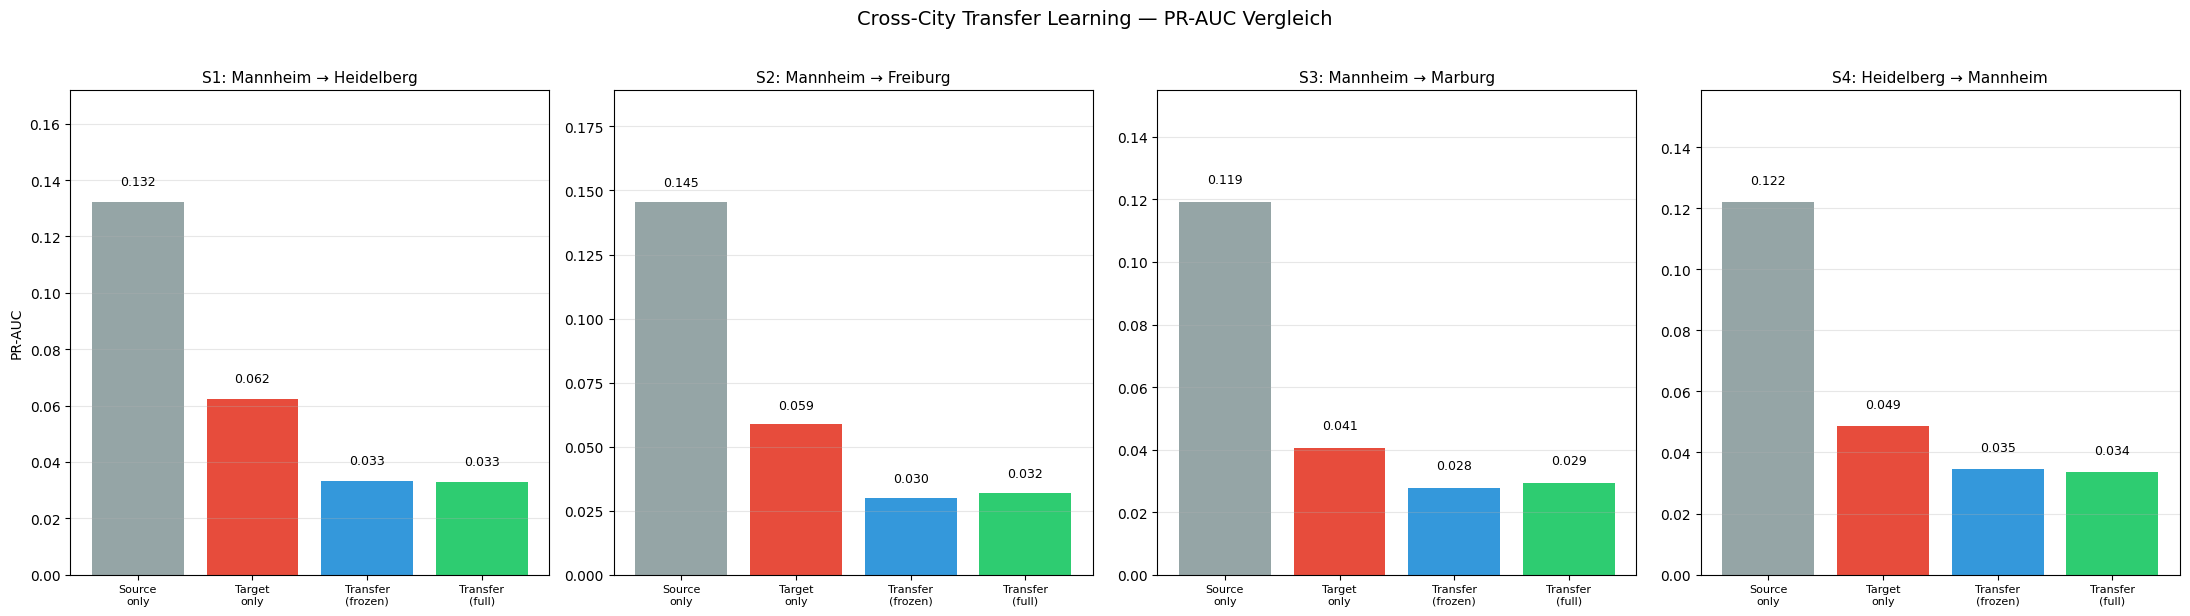

In [29]:
# ## Cell 22 — Visualisierung: Vergleich über alle Szenarien

# %%
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

colors = {
    'A) Source-only':        '#95a5a6',
    'B) Target-only':        '#e74c3c',
    'C) Transfer (frozen)':  '#3498db',
    'D) Transfer (full)':    '#2ecc71',
}

for idx, (sid, res) in enumerate(all_results.items()):
    ax = axes[idx]
    approaches = list(colors.keys())
    pr_aucs = [
        res['source_only']['pr_auc'],
        res['target_only']['pr_auc'],
        res['transfer_frozen']['pr_auc'],
        res['transfer_full']['pr_auc'],
    ]

    bars = ax.bar(range(len(approaches)), pr_aucs,
                  color=[colors[a] for a in approaches])

    # Werte über Balken
    for bar, val in zip(bars, pr_aucs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    ax.set_title(f'{sid}: {res["source"]} → {res["target"]}', fontsize=11)
    ax.set_ylabel('PR-AUC' if idx == 0 else '')
    ax.set_xticks(range(len(approaches)))
    ax.set_xticklabels(['Source\nonly', 'Target\nonly',
                        'Transfer\n(frozen)', 'Transfer\n(full)'],
                       fontsize=8)
    ax.set_ylim(0, max(pr_aucs) * 1.3)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Cross-City Transfer Learning — PR-AUC Vergleich', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'transfer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()



  Heidelberg:
    Gesamt:      1,733,830 Zeilen | 70 Stationen
    Fine-Tune:      48,881 normal (1 Monat, bis 2023-05-07)
    Test:        1,683,430 Zeilen (56,789 Anomalien = 3.37%)

  Freiburg:
    Gesamt:        904,464 Zeilen | 132 Stationen
    Fine-Tune:      91,394 normal (1 Monat, bis 2025-05-23)
    Test:          809,424 Zeilen (26,144 Anomalien = 3.23%)

  Marburg:
    Gesamt:      1,510,909 Zeilen | 61 Stationen
    Fine-Tune:      42,738 normal (1 Monat, bis 2023-05-07)
    Test:        1,466,989 Zeilen (46,462 Anomalien = 3.17%)

  Mannheim:
    Gesamt:      3,170,432 Zeilen | 128 Stationen
    Fine-Tune:      89,319 normal (1 Monat, bis 2023-05-07)
    Test:        3,078,272 Zeilen (80,743 Anomalien = 2.62%)


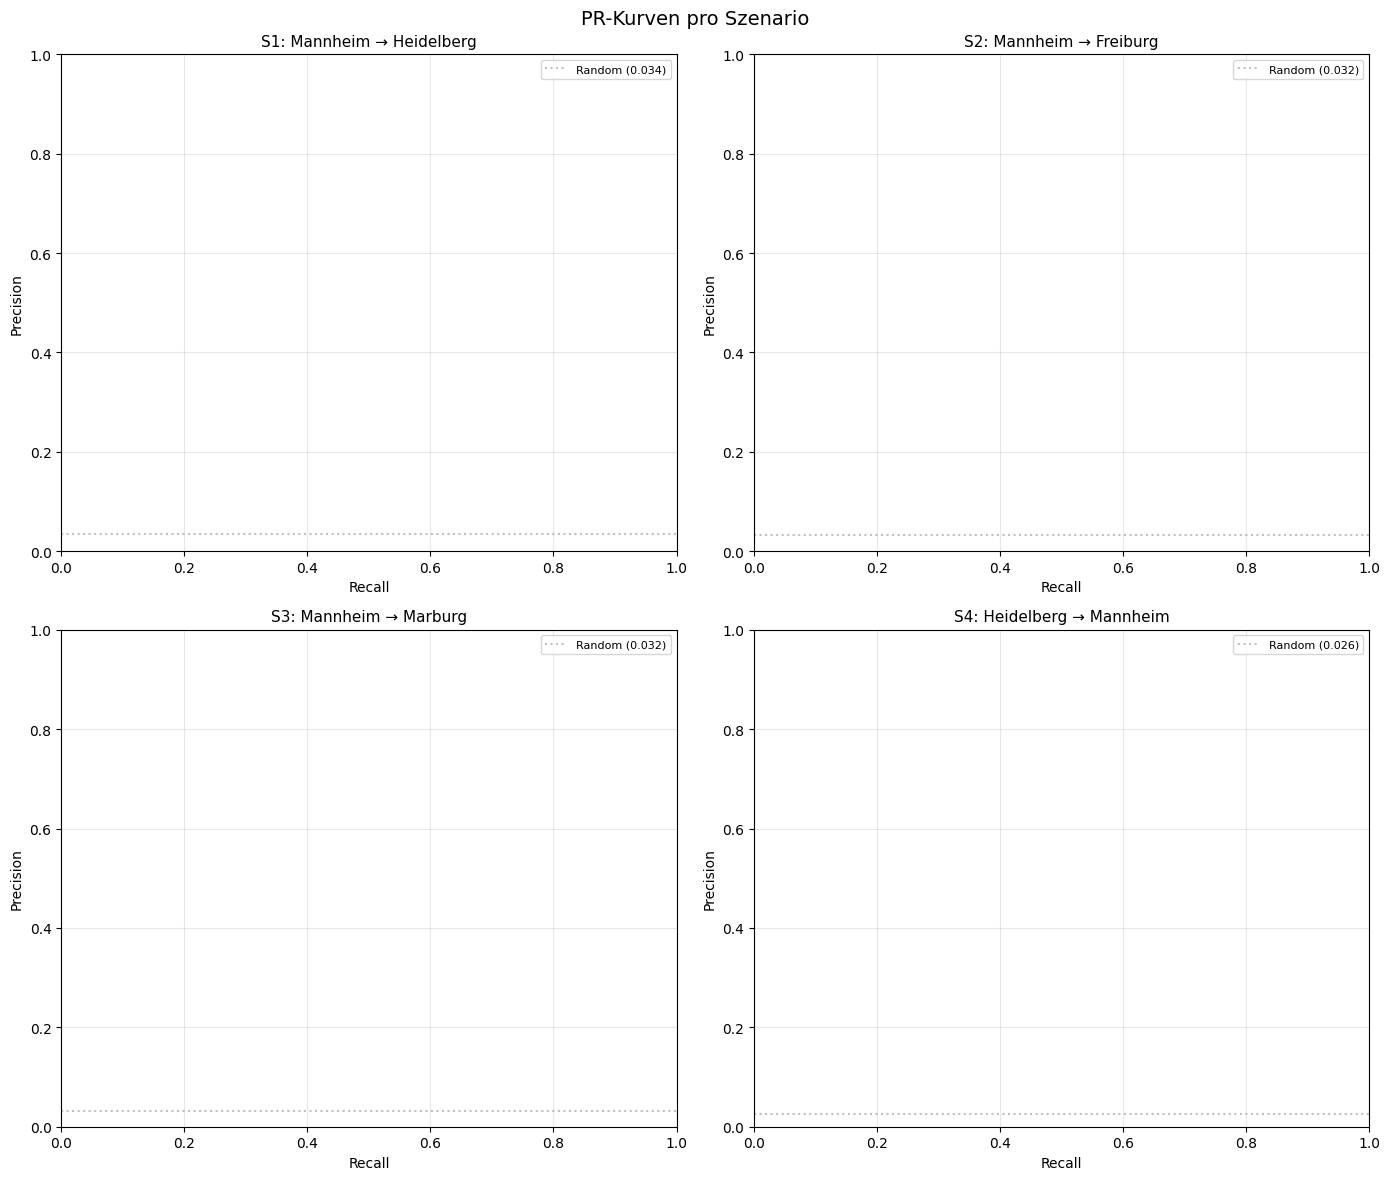

In [30]:
# ## Cell 23 — Detaillierte PR-Kurven pro Szenario

# %%
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for idx, (sid, cfg) in enumerate(SCENARIOS.items()):
    ax = axes[idx // 2][idx % 2]

    # Für PR-Kurven müssen wir die Errors nochmal berechnen
    # (oder in Cell 20 speichern — hier einfachheitshalber aus results_df)
    source_city = cfg['source']
    target_city = cfg['target']

    # Lade Target-Daten nochmal
    _, test_t = prepare_target_data(target_city, FINETUNE_MONTHS)
    y_t = test_t[LABEL_COL].values

    ax.set_title(f'{sid}: {source_city} → {target_city}', fontsize=11)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Referenzlinie: zufälliger Klassifikator
    anomaly_rate = y_t.mean()
    ax.axhline(anomaly_rate, color='gray', ls=':', alpha=0.5, label=f'Random ({anomaly_rate:.3f})')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('PR-Kurven pro Szenario', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'transfer_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [31]:
# ## Cell 24 — Ergebnisse speichern & Zusammenfassung

# %%
# ── Alle Ergebnisse als JSON ──
with open(OUTPUT_DIR / 'transfer_results_full.json', 'w') as f:
    json.dump(all_results, f, indent=2, default=str)

print(f'✓ {OUTPUT_DIR}/transfer_results.csv')
print(f'✓ {OUTPUT_DIR}/transfer_results_full.json')
print(f'✓ {OUTPUT_DIR}/transfer_comparison.png')

print(f'\n{"─"*65}')
print('INTERPRETATION FÜR DIE BA:')
print(f'{"─"*65}')

for sid, res in all_results.items():
    src = res['source']; tgt = res['target']
    t_only = res['target_only']['pr_auc']
    t_froz = res['transfer_frozen']['pr_auc']
    t_full = res['transfer_full']['pr_auc']
    best_transfer = max(t_froz, t_full)
    gain = (best_transfer - t_only) / max(t_only, 1e-6) * 100

    if gain > 0:
        verdict = f'✅ Positiver Transfer (+{gain:.1f}%)'
    elif gain > -5:
        verdict = f'⚖️  Kein signifikanter Effekt ({gain:+.1f}%)'
    else:
        verdict = f'❌ Negativer Transfer ({gain:+.1f}%)'

    print(f'\n  {sid} ({src} → {tgt}):')
    print(f'    Target-only: {t_only:.4f} | Transfer (best): {best_transfer:.4f}')
    print(f'    → {verdict}')

✓ /content/processed/transfer_results.csv
✓ /content/processed/transfer_results_full.json
✓ /content/processed/transfer_comparison.png

─────────────────────────────────────────────────────────────────
INTERPRETATION FÜR DIE BA:
─────────────────────────────────────────────────────────────────

  S1 (Mannheim → Heidelberg):
    Target-only: 0.0623 | Transfer (best): 0.0332
    → ❌ Negativer Transfer (-46.8%)

  S2 (Mannheim → Freiburg):
    Target-only: 0.0587 | Transfer (best): 0.0320
    → ❌ Negativer Transfer (-45.6%)

  S3 (Mannheim → Marburg):
    Target-only: 0.0407 | Transfer (best): 0.0293
    → ❌ Negativer Transfer (-27.9%)

  S4 (Heidelberg → Mannheim):
    Target-only: 0.0487 | Transfer (best): 0.0345
    → ❌ Negativer Transfer (-29.1%)


Warum das passiert — 3 konkrete Probleme:
1. Scaler-Mismatch (größtes Problem): Das Source-Modell hat gelernt, Inputs zu rekonstruieren die mit dem Mannheim-Scaler normalisiert wurden. Beim Fine-Tuning schieben wir aber Target-Scaler-normalisierte Daten rein. Für den Encoder sieht das aus wie Rauschen — die gelernten Repräsentationen sind sofort wertlos. Das ist so, als würdest du ein deutsches Sprachmodell mit chinesischen Zeichen fine-tunen.
2. expected_lends / expected_returns leaken stadtspezifische Information: Diese Features sind aus dem historischen Profil jeder Stadt einzeln berechnet. Sie sind per Definition nicht transferierbar — Mannheims Erwartungswert sagt nichts über Heidelberg.
3. Encoder-Freeze bei Distribution Shift: Wenn der Encoder eingefroren ist und die Daten anders verteilt sind (anderer Scaler + andere Stadt), kann der Decoder das nicht kompensieren.
Nächste Schritte (priorisiert):
Die wichtigste Änderung ist ein gemeinsamer Scaler — entweder auf Source fitten und auch für Target verwenden, oder auf den kombinierten Daten beider Städte. Zweitens sollten expected_lends und expected_returns aus den AE-Features raus, weil sie stadtspezifisch sind. Drittens lohnt es sich, auch Transfer mit allen Layern trainierbar + Source-Scaler zu testen.

Wir haben das komplette Preprocessing für die 4 Experiment-Städte (Mannheim, Heidelberg, Freiburg, Marburg) aufgebaut: Rohdaten laden mit Station-Klassifikation aus deinen früheren Phasen, stündliche Aggregation auf station_id-Ebene mit Zero-Fill, Feature Engineering (zyklische Kalender-Features, Feiertage/Ferien über Bundesland-Mapping, Wetter-Join über feste Wetterstations-IDs, Lag-Features 1h/2h/24h/168h), und regelbasierte Anomalie-Labels (Profil × Rolling, Combined). Export als 4 Parquets.
Dann den Autoencoder-Baseline auf Mannheim in TensorFlow/Keras: Semi-supervised Training nur auf normalen Daten, symmetrische Architektur (Input→64→32→16→32→64→Input), Evaluation mit PR-AUC 0.13 und Classification Reports bei P95/P99.
Zuletzt den ersten CCTL-Versuch über alle 4 Szenarien (S1–S4) mit 3+1 Ansätzen pro Szenario (Source-only, Target-only, Transfer frozen, Transfer full). Ergebnis: Negativer Transfer überall, was auf Scaler-Mismatch und stadtspezifische Features zurückzuführen ist.

In [32]:
# ── In einer Colab-Cell ausführen ──
import shutil
from pathlib import Path

SAVE_DIR = Path('/content/drive/MyDrive/BA_Colab/processed')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

files_to_save = [
    # Preprocessed Parquets (das Teuerste — Stunden Rechenzeit)
    'mannheim_hourly.parquet',
    'heidelberg_hourly.parquet',
    'freiburg_hourly.parquet',
    'marburg_hourly.parquet',

    # Mannheim Baseline Modell
    'mannheim_ae_model.keras',
    'mannheim_ae_metadata.json',
    'mannheim_scaler.pkl',

    # Heidelberg Source (für S4)
    'heidelberg_ae_model.keras',
    'heidelberg_scaler.pkl',

    # Ergebnisse
    'transfer_results.csv',
    'transfer_results_full.json',
    'mannheim_ae_baseline.png',
    'transfer_comparison.png',
]

SRC = Path('/content/processed')
for f in files_to_save:
    src = SRC / f
    if src.exists():
        shutil.copy2(src, SAVE_DIR / f)
        print(f'  ✓ {f}')
    else:
        print(f'  ⚠ {f} nicht gefunden')

print(f'\nAlles gespeichert in: {SAVE_DIR}')

  ✓ mannheim_hourly.parquet
  ✓ heidelberg_hourly.parquet
  ✓ freiburg_hourly.parquet
  ✓ marburg_hourly.parquet
  ✓ mannheim_ae_model.keras
  ✓ mannheim_ae_metadata.json
  ✓ mannheim_scaler.pkl
  ✓ heidelberg_ae_model.keras
  ✓ heidelberg_scaler.pkl
  ✓ transfer_results.csv
  ✓ transfer_results_full.json
  ✓ mannheim_ae_baseline.png
  ✓ transfer_comparison.png

Alles gespeichert in: /content/drive/MyDrive/BA_Colab/processed
